These first blocks define the functions we need to construct the FSA

In [1]:
#I want to see if an element has finite order, specifically I only check it for reflections
#since reflections are walls and walls meet in the vertices of the triangulation if they are not parallel
#one of the m1, m2, or m3 has to be a power that sends those to the unit
def triangleFinite(w,m1,m2,m3):
    #the first check is to avoid the case where mi is \infty, but the implementation uses -1 here
    #don't think the check is actually needed wince reflections are their own inverses and not the unit
    if not (m1==-1):
        if (w^m1).is_one():
            return True
    if not (m2==-1):
        if (w^m2).is_one():
            return True
    if not (m3==-1):
        if (w^m3).is_one():
            return True
    else:
        return False

In [2]:
#checks is r1 seperates r2 from the identity, a wall seperates itself from the identity is the convention I went with
#either convention requires a case distinction at different parts
def seperateFromOne(r1,r2,m1,m2,m3):
    r=r1*r2
    #check 1: they are inverses
    if (r1*(r2^-1)).is_one():
        return True
    #check 2: they have finite order, i.e. the walls intersect
    if triangleFinite(r,m1,m2,m3):
        return False
    #check 3: they are distinct and parallel, actual reflection of r2 along r1 if r1*r2*r1^-1, but if that is shorter than r2
    #then r1*r2 has to be shorter as well since as conjugates of simple reflections we can do the simplifications to a geodesi
    #word on both sides, i.e. r1*r2 can be made shorter than r2
    elif (r).length()<(r2).length():
        return True
    else:
        return False

In [3]:
def wallsOfOne(G,m1,m2,m3):
    #fin is the indicator for the process of finding walls, parallel is a statement about the current wall being checked
    fin=False
    parallel=False
    #Initializing the list with the walls of the fundamental chamber, so start check at walls gsg^-1 where g has length 1
    #I might return and change stuff from reduced words to elements, especially since in the FSA I ended up needing elements
    #but reduced words are fantastic for debugging
    n=1
    s=G.simple_reflections()
    H=[]
    for t in s:
        H.append(tuple(t.reduced_word()))
    while fin==False:
        #print statements are debugging artifacts I plan on keeping until I'm done messing with the code
        #print(n)
        #if we find any new walls at our current radius we stop, if we find a new wall we flip this and continue
        fin=True
        #looking at walls at distance n from the identity
        for g in list(G.elements_of_length(n)):
            #got 3 reflections around any point, redcing this to 2 is possible, but I don't know if it would be faster
            for t in s:
                #we assume the new wall is not seperated from 1 until we find a wall in H that does
                parallel=False
                #the reflection we are checking
                gRef=g*t*(g^-1)
                #print(gRef.reduced_word())
                #checking if it is a new one
                for rl in H:
                    #convert the reduced word to group element
                    r=G.from_reduced_word(rl)
                    #check if g is seperated from the unit by this wall, if it is seperated we can ignore it
                    if seperateFromOne(r,gRef,m1,m2,m3):
                            parallel=True
                            #print("seperated by ")
                            #print(rl)
                            #print(" ")
                #if we found a new wall add (a reduced word for it) to the list
                #also need to look a layer deeper
                if parallel==False:
                    H.append(tuple(gRef.reduced_word()))
                    fin=False
        #increase the search radius
        n=n+1
    return H
                

In [4]:
#reflections seerating an element from the unit bring it closer, reflections act on group elements by left multiplication
def seperateFromOneElem(r,g):
    if (r*g).length()<g.length():
        return True
    else:
        return False

In [5]:
#find all the walls seperating g, that are not seperated from g by another wall
def wallsOfElem(G,g,m1,m2,m3):
    #all walls seperating g from e are represented in (any) shortest representative
    l=g.length()
    w=g.reduced_word()
    #closest one is definitely one of them, initialize the list with that
    #another place where I may switch to elements instead of reduced words later
    h=G.from_reduced_word(w[:l-1])
    r=G.from_reduced_word([w[l-1]])
    #making the respective reflection
    ref=h*r*(h^-1)
    Wg=[]
    Wg.append(tuple(ref.reduced_word()))
    #work down, it is entirely possible for there to be a dry spell between the seperating walls
    #e.g. the points not in the polyhedra adjacent to the unit that still get sent to it by the voracious projection
    for i in range(l):
        #check if seperated by one closer
        parallel=False
        #previous version had a different upper bound for i, which had underflow issues
        #this can probably be removed again, but I'm just adding comments on this pass
        k=max(l-i-1,0)
        #build reflection
        h=G.from_reduced_word(w[:k])
        r=G.from_reduced_word([w[k]])
        ref=h*r*(h^-1)
        #check if it is a new one
        for rl in Wg:
            r2=G.from_reduced_word(rl)
            #check if we should not add
            if seperateFromOne(ref,r2,m1,m2,m3):
                parallel=True
        if parallel==False:
            Wg.append(tuple(ref.reduced_word()))
    return Wg
        

In [6]:
#implementing the voracious projection
def voraciousProj(G,g,m1,m2,m3):
    Wg=wallsOfElem(G,g,m1,m2,m3)
    lmin=len(Wg)
    #listing all the geodesics, going backwards on all of them we will encounter the voracious representation by seeing which one crosses all of Wg first
    Can=g.reduced_words()
    l=g.length()
    #the voracious projection is passed by one of the geodesic, since they have to pass |Wg| walls we skip ahead to that many steps into the process
    for i in range(lmin-1,l+1):
        #get the candidates of the specified lengths
        CanTemp=[]
        for h in Can:
            CanTemp.append(h[:l-i])
        #check if any of the candidates are seperated from g by all of Wg, i.e. none of Wg seperates the candidate from the unit
        for p in CanTemp:
            seperate=True
            for rl in Wg:
                r=G.from_reduced_word(rl)
                if seperateFromOneElem(r,G.from_reduced_word(p)):
                    seperate=False
            if seperate==True:
                return G.from_reduced_word(p)
        Can=CanTemp
    return g

In [7]:
#find the elements that have voracious projection to the unit
def vorProjOne(G,m1,m2,m3):
    projElem=[]
    done=False
    l=1
    #since the voracious projection preserves the ordering h\leq g iff there is a geodesic word for g starting with a geodesic word for h
    #we stop looking when we hit a radius where there are no new ones
    #this one can probably be drastically improved with that fact by being more restrictive with the candidates
    #that does require rewriting how we construct the candidate list
    while not done:
        done=True
        tempCand=G.elements_of_length(l)
        l=l+1
        for g in tempCand:
            if voraciousProj(G,g,m1,m2,m3).is_one():
                projElem.append(g)
                done=False
    return projElem

In [8]:
#we translate several sets of walls by the action of an element, since walls are represented by reflections this action is conjugation
def actionElemOnWalls(G,g,Walls):
    gWalls=[]
    for rl in Walls:
        r=G.from_reduced_word(rl)
        #troubleshooting artifact can likely be removed
        g1=G.from_reduced_word(g.reduced_word())
        gWalls.append(tuple(((g1)*r*((g1)^-1)).reduced_word()))
    return gWalls

In [9]:
from sage.combinat.finite_state_machine import FSMState
#Setting up the FSA, only establishing the states from the walls around the unit and setting them as accepting
def setupVorFSA(U):
    States=[]
    P=list(subsets(U))
    for u in P:
        #labels need to be hashable, and for our purposes not care about order, frozensets satisfy those conditions
        States.append(FSMState(frozenset(u),is_final=True))
    VorFSA=Automaton()
    VorFSA.add_states(States)
    #moved this to the FSA construction, don't remember why, probably some bug
    #(VorFSA.state(frozenset(()))).is_initial=True
    return VorFSA

In [10]:
#first of the two conditions for an edge being drawn is that no element of A seperates g from the unit
def vorFSACheckSepFromOne(G,A,g):
    for rl in A:
        if seperateFromOneElem(G.from_reduced_word(rl),g):
            return True
    return False

In [11]:
#second condition is that each element of A is seperated from g by another wall
#if one of these elements is seperated from g by another wall, it is seperated by a wall in Wg
#to use previously established functions we then translate both by g, so we are checking if elements of g*a*g^-1
#are seperated from the unit by an element of g*(Wg)*g^-1
def vorFSACheckSepFromElem(G,A,g,Wg,m1,m2,m3):
    #translate to the unit
    B=actionElemOnWalls(G,g^-1,A)
    Hg=actionElemOnWalls(G,g^-1,Wg)
    for r1l in B:
        seperate=False
        for r2l in Hg:
            r1=G.from_reduced_word(r1l)
            r2=G.from_reduced_word(r2l)
            #need to exclude them being the same
            if seperateFromOne(r2,r1,m1,m2,m3) and (not (r1*(r2^-1)).is_one()):
                seperate=True
        #if we found one that isn't seperated we are done
        if seperate==False:
            return False
    return True

In [12]:
from sage.combinat.finite_state_machine import FSMState, FSMTransition
#given the coefficients for our triangle group we want to build the FSA
def constructVorFSA(m1,m2,m3):
    #construct the group and the walls
    W=CoxeterGroup(matrix([[1,m1,m2],[m1,1,m3],[m2,m3,1]]))
    U=wallsOfOne(W,m1,m2,m3)
    #another debugging artifact that can probably be removed
    UStates=[]
    for u in U:
        UStates.append(W.from_reduced_word(u))
    #finding the points that project to the unit
    ProjPts=vorProjOne(W,m1,m2,m3)
    #set up the states and the initial state
    VFSA=setupVorFSA(UStates)
    #print(list(VFSA.states()))
    (VFSA.state(frozenset([]))).is_initial=True
    #loop over the points that give us our transitions
    for g in ProjPts:
        #fine the data for the transition
        #Words is the list of geodesic words for g that each give us a long transition, Wg is needed for the endpoint
        Words=g.reduced_words()
        Wg=wallsOfElem(W,g,m1,m2,m3)
        l=g.length()
        #print(" ")
        #print(g.reduced_word())
        #print(Wg)
        #need to get it in the right format
        gInvWg=[]
        for temp in actionElemOnWalls(W,g^-1,Wg):
            gInvWg.append(W.from_reduced_word(temp))
            #print(temp)
        StateOfg=VFSA.state(frozenset(gInvWg))
        #Go over all states and see if it is the start point
        for AS in VFSA.final_states():
            AElem=AS.label()
            #this bouncing back and forth between words and elements might be simplified
            A=[]
            for elem in AElem:
                A.append(elem.reduced_word())
            #print(A)
            #check if the states get connected
            if (not vorFSACheckSepFromOne(W,A,g)) and vorFSACheckSepFromElem(W,A,g,Wg,m1,m2,m3):
                #we need to add a long edge consisting of many small transitions between non-accpeting states for each geodesic word
                for labels in Words:
                    #start this chain at the start
                    State1=AS
                    for i in range(l-1):
                        #to make sure the states are distinct the label contains the start, the element, the word and how far into the word we are
                        State2=FSMState((g,AS.label(),tuple(labels),i),is_final=False)
                        VFSA.add_state(State2)
                        VFSA.add_transition(FSMTransition(State1,State2,labels[i]))
                        #setup the next step in the chain
                        State1=State2
                    #connect the chain to the accept state
                    VFSA.add_transition(FSMTransition(State1,StateOfg,labels[l-1]))
    #we calculated these and they are still useful
    return VFSA, U, ProjPts

In [13]:
import time
#this loops over the coefficients I want to use and makes the date for all the triangle groups (with coefficients increasig in the order of the list) and outputs a dictionary labeled with the tuple for the data
def makeData(listCoeffs):
    t0=time.time()
    Data=dict()
    Coeffs=listCoeffs
    l=len(Coeffs)
    #loop over the triples in increasing order
    for i in range(l):
        for j in range(i,l):
            for k in range(j,l):
                #since the code is slow I print this amount opf progress, also great for debugging (is how I know 235 and 236 caused issues
                print((Coeffs[i],Coeffs[j],Coeffs[k]))
                tStart=time.time()
                FSA, U, ProjPts=constructVorFSA(Coeffs[i],Coeffs[j],Coeffs[k])
                tEnd=time.time()
                print(tEnd-tStart)
                Data[(Coeffs[i],Coeffs[j],Coeffs[k])]=(FSA, U, ProjPts, tEnd-tStart)
    #saving is now the responsability of the user, but gets saved as a .sobj if you use this
    #save(Data,"TriangleVoraciousDataBig")
    t1=time.time()
    print(t1-t0)
    return Data

In [14]:
#Making the data that does save
Data=makeData([2,3,4,-1])

(2, 2, 2)
0.21394014358520508
(2, 2, 3)
0.04049396514892578
(2, 2, 4)
6.508759021759033
(2, 2, -1)
0.4858741760253906
(2, 3, 3)
0.33031749725341797
(2, 3, 4)
21.40259027481079
(2, 3, -1)
1.4425504207611084
(2, 4, 4)
95.61659502983093
(2, 4, -1)
5.000267028808594
(2, -1, -1)
0.4880368709564209
(3, 3, 3)
0.20312952995300293
(3, 3, 4)
37.583948612213135
(3, 3, -1)
3.5062053203582764
(3, 4, 4)
78.04768371582031
(3, 4, -1)
12.31494688987732
(3, -1, -1)
2.0332751274108887
(4, 4, 4)
204.21721243858337
(4, 4, -1)
26.34493327140808
(4, -1, -1)
6.885511159896851
(-1, -1, -1)
0.29131174087524414
502.9597682952881


In [15]:
#saved incase this window desynchs and I cant run it in time for the presentation
save(Data,"TriangleVoraciousDataPresentation")

In [16]:
#example of data
FSAEx=(Data[(2,2,-1)])[0]

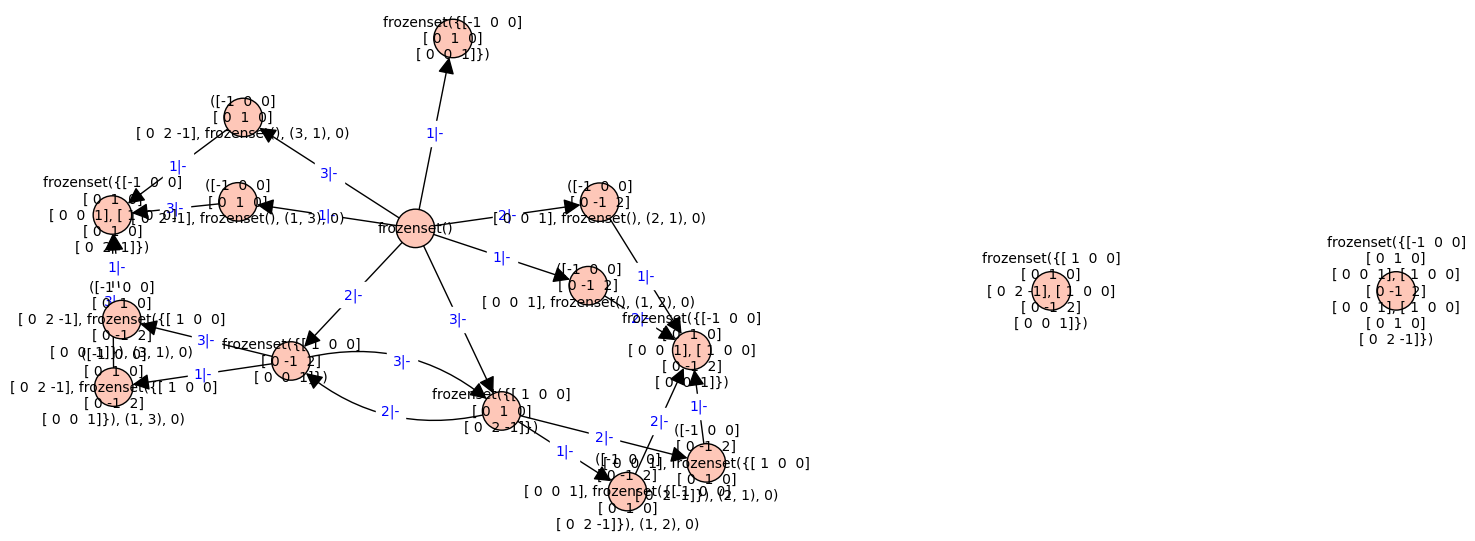

In [17]:
#it can actually graph this one unlike the others
(FSAEx.graph()).show(figsize=(15,15),edge_labels=True)

In [18]:
#Constructing the minimal FSAs
import time
t0=time.time()
Coeffs=[2,3,4,-1]
l=len(Coeffs)
DataMinFSA=dict()
for i in range(l):
        for j in range(i,l):
            for k in range(j,l):
                print((Coeffs[i],Coeffs[j],Coeffs[k]))
                FSA=Data[(Coeffs[i],Coeffs[j],Coeffs[k])][0]
                tStart=time.time()
                #FSA needs to know its alphabet for the minimization algo, I think this just goes over all adges and collects those labels
                FSA.determine_input_alphabet()
                FSAB=FSA.minimization()
                DataMinFSA[(Coeffs[i],Coeffs[j],Coeffs[k])]=FSAB
                tEnd=time.time()
                print(FSA)
                print(FSAB)
                print(tEnd-tStart)
                print(" ")

t1=time.time()
print(t1-t0)
save(DataMinFSA,"MinimizedFSAsData")

(2, 2, 2)
Automaton with 26 states
Automaton with 9 states
0.0368494987487793
 
(2, 2, 3)
Automaton with 62 states
Automaton with 13 states
0.11493778228759766
 
(2, 2, 4)
Automaton with 124 states
Automaton with 17 states
1.235173225402832
 
(2, 2, -1)
Automaton with 16 states
Automaton with 8 states
0.06795859336853027
 
(2, 3, 3)
Automaton with 276 states
Automaton with 25 states
0.9438364505767822
 
(2, 3, 4)
Automaton with 1676 states
Automaton with 49 states
47.221890449523926
 
(2, 3, -1)
Automaton with 36 states
Automaton with 10 states
0.23966288566589355
 
(2, 4, 4)
Automaton with 2088 states
Automaton with 59 states
78.01746582984924
 
(2, 4, -1)
Automaton with 72 states
Automaton with 12 states
0.9680595397949219
 
(2, -1, -1)
Automaton with 12 states
Automaton with 6 states
0.05096721649169922
 
(3, 3, 3)
Automaton with 328 states
Automaton with 41 states
2.6054065227508545
 
(3, 3, 4)
Automaton with 632 states
Automaton with 49 states
46.355908155441284
 
(3, 3, -1)
Autom

In [19]:
#prints the language of the last FSA in the previous loop up to a certain word length
#note that this is the same format as the reduced words for Coxeter groups
list(FSA.language(max_length=3))

[[],
 [1],
 [2],
 [3],
 [1, 2],
 [3, 2],
 [1, 3],
 [2, 3],
 [2, 1],
 [3, 1],
 [1, 2, 1],
 [1, 3, 1],
 [2, 3, 1],
 [3, 2, 1],
 [1, 2, 3],
 [2, 1, 3],
 [3, 1, 3],
 [3, 2, 3],
 [1, 3, 2],
 [2, 1, 2],
 [2, 3, 2],
 [3, 1, 2]]

In [20]:
Data1=load("TriangleVoraciousDataPresentation.sobj")

In [21]:
FSA1=Data1[(2,2,-1)][0]

In [22]:
FSA1

Automaton with 16 states

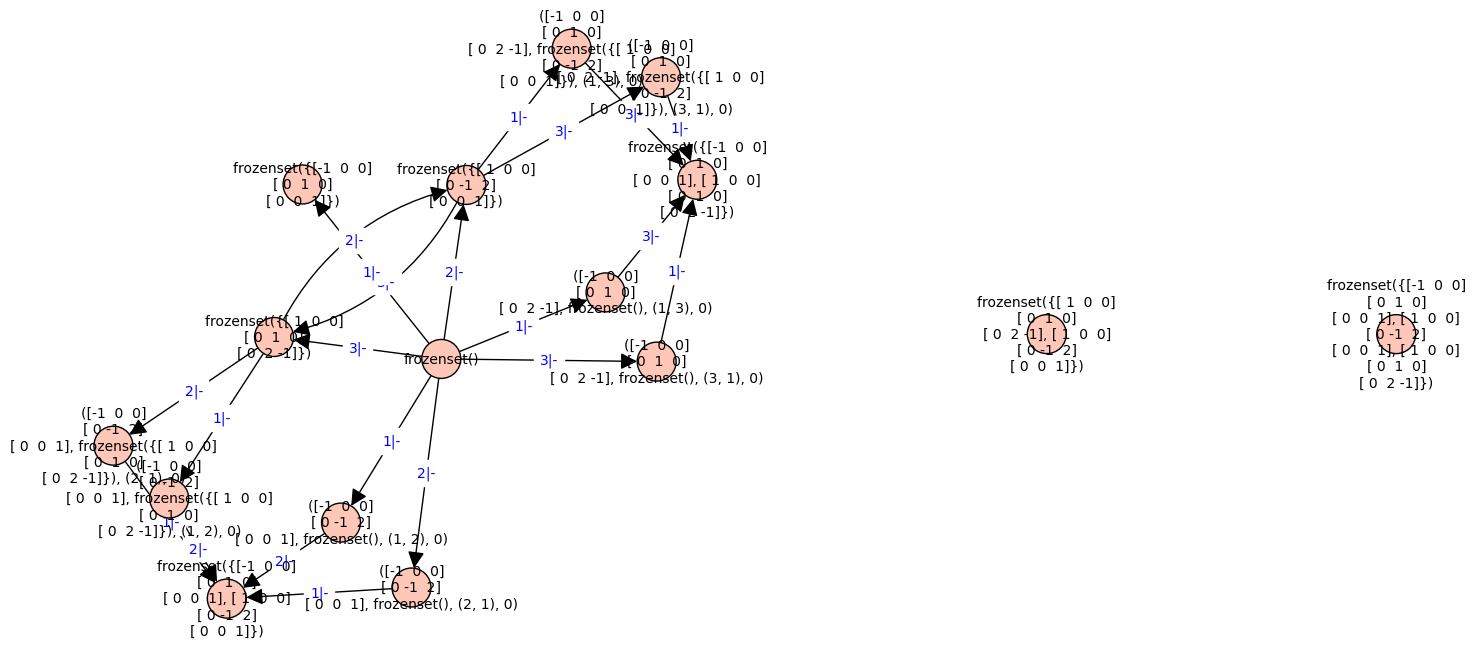

In [23]:
(FSA1.graph()).show(figsize=(15,15),edge_labels=True)

In [24]:
FSA1.determine_alphabets()
FSA1Min=FSA1.minimization()

In [25]:
FSA1Min

Automaton with 8 states

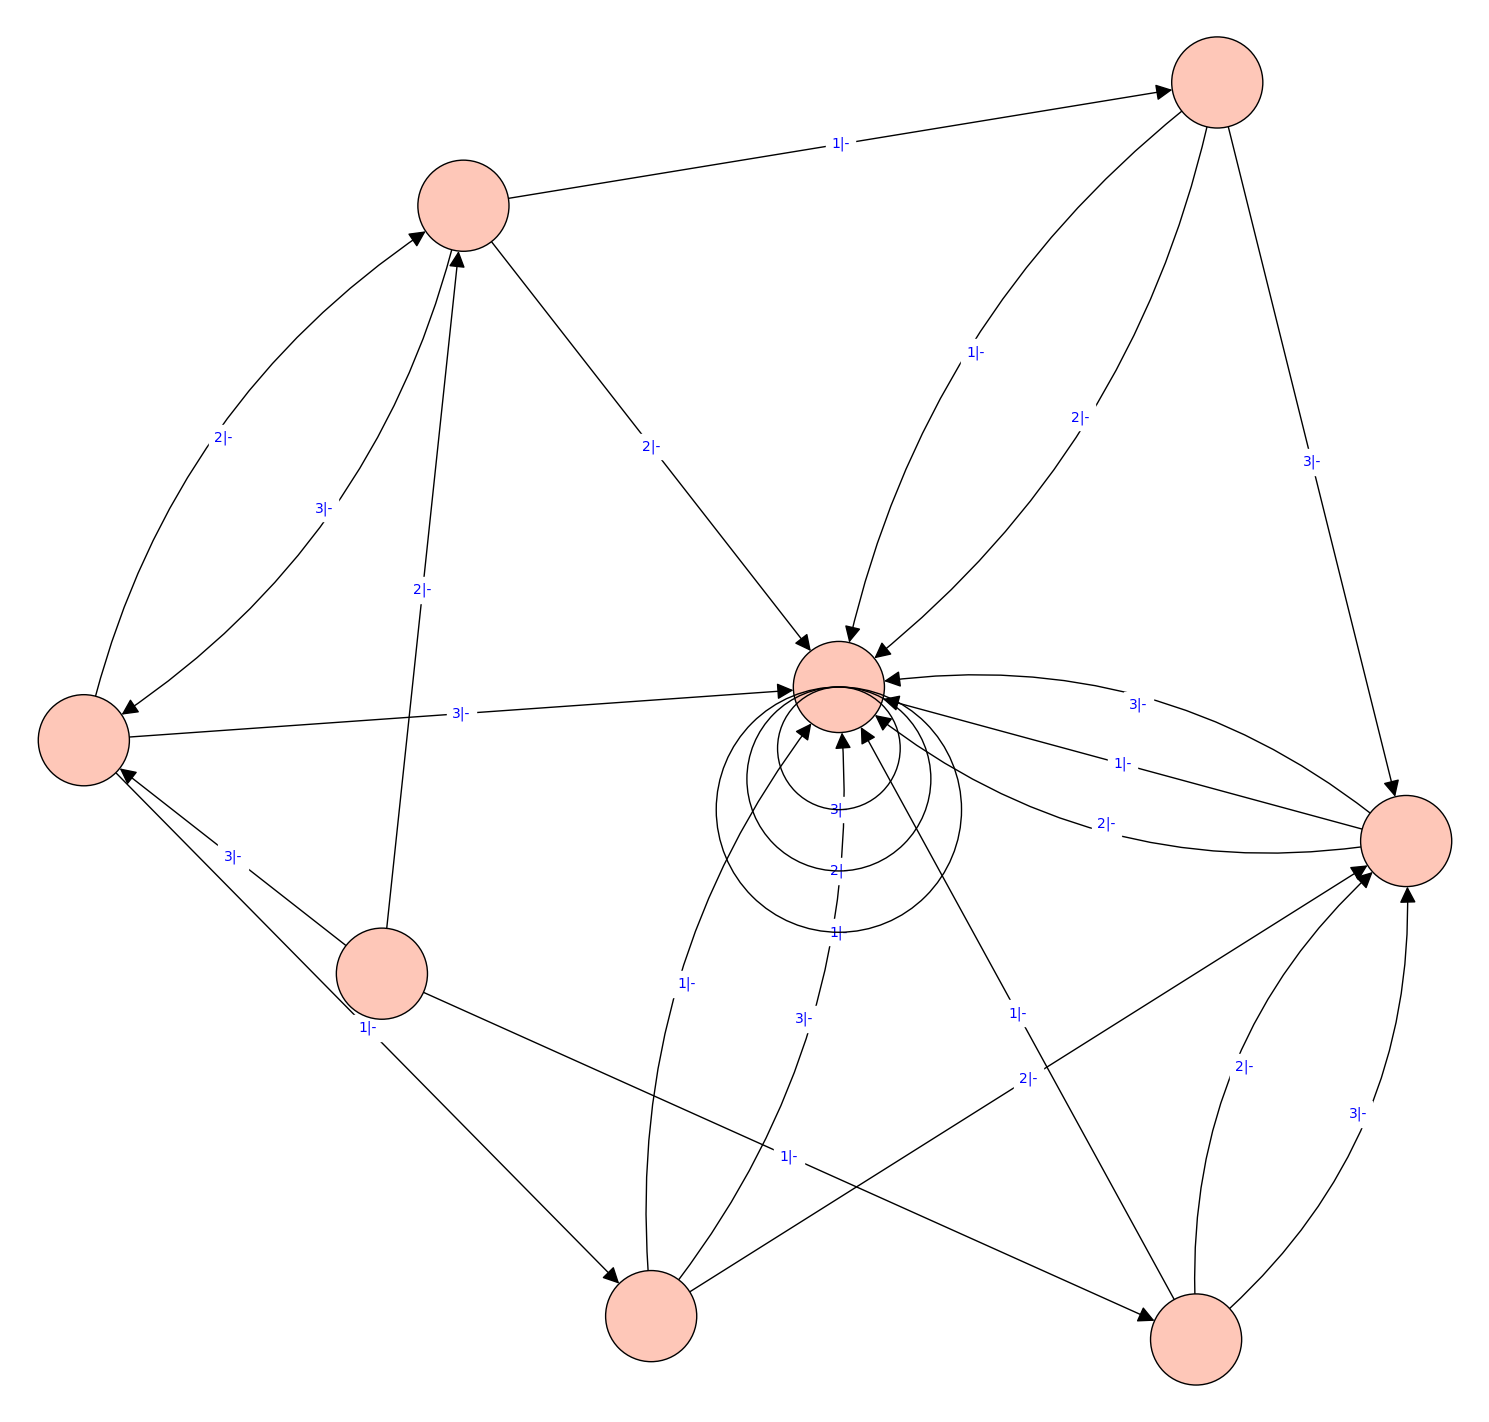

In [26]:
(FSA1Min.graph()).show(figsize=(15,15),edge_labels=True,vertex_labels=False)